In [1]:
from pathlib import Path
import pandas as pd
import seaborn as sns
from tqdm.notebook import tqdm
from concurrent.futures import ThreadPoolExecutor, as_completed
from subprocess import run, PIPE
import os
import torch
import matplotlib.pyplot as plt
import numpy as np

In [2]:
DATA_PATH = Path("/mnt/data/kusnierz/audio-data/WildSVDD/downloads")

In [3]:
files = [p for p in DATA_PATH.rglob("*") if p.is_file() and p.suffix.lower() == ".flac"]

def ffprobe_duration(path: Path):
    cmd = [
        "ffprobe", "-v", "error",
        "-show_entries", "format=duration",
        "-of", "default=noprint_wrappers=1:nokey=1",
        str(path)
    ]
    proc = run(cmd, stdout=PIPE, stderr=PIPE, text=True)
    if proc.returncode != 0 or not proc.stdout.strip():
        return {"error": True, "filepath": str(path), "error_msg": proc.stderr.strip() or "no-duration"}
    try:
        dur = float(proc.stdout.strip())
        return {"filename": path.stem, "filepath": str(path), "duration": int(dur)}
    except Exception as e:
        return {"error": True, "filepath": str(path), "error_msg": repr(e)}

results = []
failed = []
max_workers = min(32, max(4, (os.cpu_count() or 4) * 2))
with ThreadPoolExecutor(max_workers=max_workers) as ex:
    futures = {ex.submit(ffprobe_duration, p): p for p in files}
    for fut in tqdm(as_completed(futures), total=len(futures)):
        res = fut.result()
        if res.get("error"):
            failed.append((res["filepath"], res["error_msg"]))
        else:
            results.append(res)

df = pd.DataFrame(results)
failed_df = pd.DataFrame(failed, columns=["filepath", "error"])
print("success:", len(df), "failed:", len(failed_df))

  0%|          | 0/963 [00:00<?, ?it/s]

success: 963 failed: 0


In [4]:
df.describe()

,duration
count,963.000000
mean,235.075805
std,144.453575
min,11.000000
25%,197.000000
50%,233.000000
75%,267.000000
max,3600.000000


<Axes: xlabel='duration', ylabel='Count'>

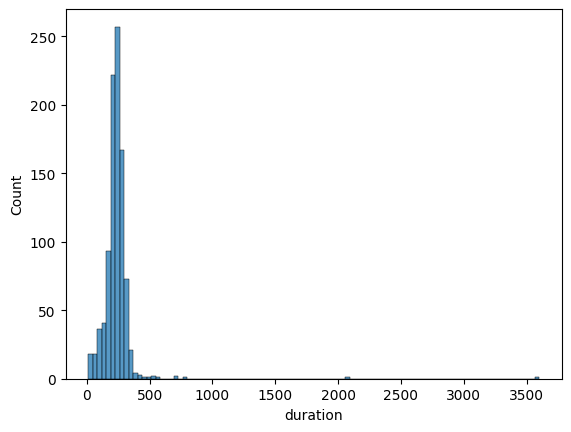

In [5]:
sns.histplot(df, x='duration', bins=100)

In [6]:
filtered_df = df[df['duration'] < 1000]

<Axes: xlabel='duration', ylabel='Count'>

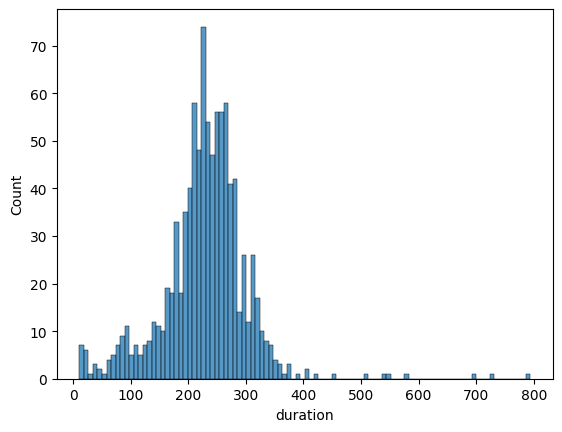

In [7]:
sns.histplot(filtered_df, x='duration', bins=100)

In [8]:
df[df['duration'] > 500].count()

filename    9
filepath    9
duration    9
dtype: int64

In [10]:
df[df['duration'] > 500]['filepath']

42     /mnt/data/kusnierz/audio-data/WildSVDD/downloa...
130    /mnt/data/kusnierz/audio-data/WildSVDD/downloa...
187    /mnt/data/kusnierz/audio-data/WildSVDD/downloa...
251    /mnt/data/kusnierz/audio-data/WildSVDD/downloa...
263    /mnt/data/kusnierz/audio-data/WildSVDD/downloa...
588    /mnt/data/kusnierz/audio-data/WildSVDD/downloa...
679    /mnt/data/kusnierz/audio-data/WildSVDD/downloa...
927    /mnt/data/kusnierz/audio-data/WildSVDD/downloa...
934    /mnt/data/kusnierz/audio-data/WildSVDD/downloa...
Name: filepath, dtype: object

In [11]:
files_to_remove = df[df['duration'] > 500]['filepath']
for filepath in files_to_remove:
    if os.path.exists(filepath):
        os.remove(filepath)
        print(f"Removed: {filepath}")
    else:
        print(f"File not found: {filepath}")

Removed: /mnt/data/kusnierz/audio-data/WildSVDD/downloads/Training_JJ_Lin_林俊傑_JJ_Lin_-_可惜沒如果_I_bonafide.flac
Removed: /mnt/data/kusnierz/audio-data/WildSVDD/downloads/Training_Beyonce_Beyoncé_-_All_Night__bonafide.flac
Removed: /mnt/data/kusnierz/audio-data/WildSVDD/downloads/Training_Beyonce_Beyoncé_Live_at_NFL__bonafide.flac
Removed: /mnt/data/kusnierz/audio-data/WildSVDD/downloads/Training_Beyonce_Top_100_Beyonce_Most_bonafide.flac
Removed: /mnt/data/kusnierz/audio-data/WildSVDD/downloads/Training_Tengger_【腾格尔】《天堂》_哔哩哔哩_bilib_bonafide.flac
Removed: /mnt/data/kusnierz/audio-data/WildSVDD/downloads/Training_D.O_🎹_디오(도경수)_-_Sugarcoa_deepfake.flac
Removed: /mnt/data/kusnierz/audio-data/WildSVDD/downloads/Training_Taylor_Swift_Taylor_Swift_&_The_D_deepfake.flac
Removed: /mnt/data/kusnierz/audio-data/WildSVDD/downloads/Training_Taylor_Swift_AI_voice_over_Taylor_deepfake.flac
Removed: /mnt/data/kusnierz/audio-data/WildSVDD/downloads/Training_Tengger_腾格尔《父亲的草原母亲的河》-个人精华《_bonafide.flac
